In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

Carga de las librerías, del modelo final guardado por `04_model_training.ipynb` (`models/mallorca/price_model.pkl`, `models/mallorca/model_metadata.json`) y del test (`data/processed/mallorca/listings_test.csv`). Este notebook no reentrena nada, parte de lo que ya quedó guardado.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
final_pipeline = joblib.load(f"{PROJECT_DIR}/models/mallorca/price_model.pkl")

with open(f"{PROJECT_DIR}/models/mallorca/model_metadata.json") as f:
    metadata = json.load(f)

test_df = pd.read_csv(f"{PROJECT_DIR}/data/processed/mallorca/listings_test.csv")
metadata["test_metrics"]

{'modelo': 'Hist Gradient Boosting (final)',
 'RMSE': 605.9437508368522,
 'MAE': 212.12461842440328,
 'R2': 0.5429289937482078,
 'MAPE': 30.616312888325258,
 'R2_log': 0.7796526364957922}

## 2. Reconstruir predicciones

Mismos `feature_cols`/`target` que en el entrenamiento (guardados en `metadata`), para tener `y_test` y las predicciones disponibles para todo el análisis que sigue.

### 2.1 X e y de test

In [3]:
feature_cols = metadata["feature_cols"]
target_col = metadata["target"]

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

bool_cols = X_test.select_dtypes(include="bool").columns
X_test[bool_cols] = X_test[bool_cols].astype(int)

X_test.shape

(2209, 118)

### 2.2 Función `evaluate`

In [4]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

### 2.3 Predecir

El modelo predice en escala `log1p(price)`; se deshace con `expm1` antes de evaluar nada.

In [5]:
pred = np.expm1(final_pipeline.predict(X_test))
residuals = pred - y_test.values

evaluate(y_test, pred, "Hist Gradient Boosting")

{'modelo': 'Hist Gradient Boosting',
 'RMSE': np.float64(605.9437508368522),
 'MAE': 212.12461842440328,
 'R2': 0.5429289937482078,
 'MAPE': np.float64(30.616312888325258)}

Coincide exactamente con `metadata["test_metrics"]` (RMSE=605,94€, MAE=212,12€, R²=0,54, MAPE=30,62%): el modelo cargado predice igual que cuando se guardó, así que el análisis de errores parte de una base fiable.

Como se vio en `04_model_training.ipynb`, ningún `district_*` ni `neighbourhood_price_encoded` entró en el top 15 de importancia — un matiz propio de Mallorca que conviene tener presente al leer los errores por zona en la sección 4: si un municipio sale mal, no es porque el modelo "no sepa dónde está", sino por otra causa.

## 3. Predicción vs. realidad

Scatter de precio predicho contra precio real, y distribución de los residuos (`predicho - real`). El objetivo es detectar sesgos sistemáticos que un único R² no muestra.

### 3.1 Predicho vs. real

(0.0, 2000.0)

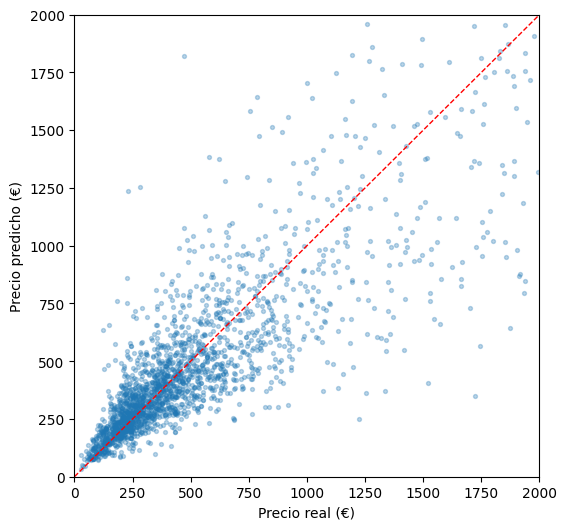

In [6]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, s=8, alpha=0.3)
lims = [0, 2000]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Precio real (€)")
plt.ylabel("Precio predicho (€)")
plt.xlim(lims)
plt.ylim(lims)

Para precios bajos y medios los puntos siguen razonablemente la diagonal. A partir de unos 800-1000€, cada vez más puntos caen por debajo: **el modelo tiende a subestimar los anuncios más caros**, el mismo patrón que en las otras cinco ciudades. El gráfico se recorta en 2000€ por claridad visual (95,4% del test); las villas más caras del test llegan hasta 22.260€ y quedan fuera de esta ventana (se tratan en la sección 5).

### 3.2 Distribución de los residuos

Media: -80.25634703886047
Mediana: -0.47069860617874326


(-1500.0, 1500.0)

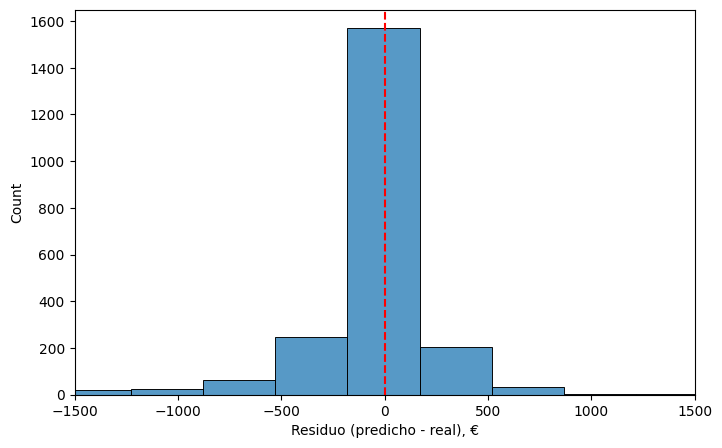

In [7]:
print("Media:", residuals.mean())
print("Mediana:", np.median(residuals))

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=60)
plt.axvline(0, color="r", linestyle="--")
plt.xlabel("Residuo (predicho - real), €")
plt.xlim(-1500, 1500)

La mediana del residuo es prácticamente 0 (-0,47€), pero la **media es -80,26€**, muchísimo más negativa — la misma lección que en las otras ciudades, pero más extrema: hay una cola de subestimaciones muy grandes en una sola dirección que arrastra la media, aunque la mitad de los anuncios se acierten casi exactos.

### 3.3 ¿El sesgo depende del precio?

(0.0, 2000.0)

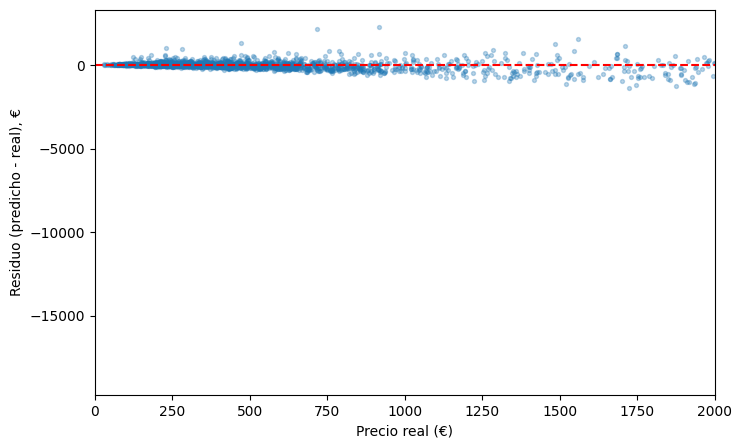

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, residuals, s=8, alpha=0.3)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Precio real (€)")
plt.ylabel("Residuo (predicho - real), €")
plt.xlim(0, 2000)

In [9]:
price_quintile = pd.qcut(y_test, 5)
pd.DataFrame({"residual": residuals}).groupby(price_quintile, observed=True)["residual"].agg(["mean", "median", "count"])

,mean,median,count
price,,,
"(28.409, 218.322]",43.635850,28.874330,442
"(218.322, 331.0]",45.017888,21.996053,443
"(331.0, 478.264]",24.329580,4.606223,440
"(478.264, 815.086]",-27.423829,-62.519813,442
"(815.086, 22260.0]",-486.651410,-312.942140,442


Confirmado con números: en los dos quintiles más baratos el residuo medio es **positivo** (+43,6€, +45,0€: el modelo sobreestima los anuncios más baratos), el tercero está casi en cero (+24,3€ de media, +4,6€ de mediana), el cuarto ya es negativo (-27,4€ de media, -62,5€ de mediana), y en el quintil más caro (por encima de 815€) el residuo medio es **-486,7€** (mediana -312,9€) — con enorme diferencia, la subestimación más severa de las seis ciudades en euros absolutos, coherente con ser también la ciudad con la cola de precio más extrema del proyecto (villas de hasta 22.260€ en el propio test).

Misma explicación que en las otras ciudades: al optimizar sobre `log1p(price)`, un error relativo pequeño en la cola alta se traduce en un error absoluto enorme al deshacer el logaritmo, y aquí la cola alta es mucho más extrema que en cualquier ciudad urbana del proyecto. El sesgo hacia sobreestimar lo barato y subestimar lo caro es una limitación real del modelo, no una anécdota.

## 4. Errores por segmento

MAE/RMSE desglosados por `room_type`, por municipio y por rango de precio.

### 4.1 Por `room_type`

In [10]:
room_type_cols = [c for c in feature_cols if c.startswith("room_type_")]
room_type_series = X_test[room_type_cols].idxmax(axis=1).str.replace("room_type_", "", regex=False)

rows = []
for rt in room_type_series.unique():
    mask = (room_type_series == rt).values
    scores = evaluate(y_test[mask], pred[mask], rt)
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
Entire home/apt,625.25,222.76,0.53,31.02,2072
Private room,88.77,51.67,0.88,24.85,131
Hotel room,50.24,42.80,-0.80,16.79,6


`Entire home/apt` (2072 filas, el 94% del test) tiene el RMSE/MAE más altos en euros (625,25€/222,76€), esperable por ser la categoría con precios más altos y dispersos (incluidas todas las villas). `Private room` tiene errores mucho más bajos (MAE=51,67€) y un R² mucho mejor (0,88 vs. 0,53). `Hotel room` (6 filas, R² negativo) no tiene muestra suficiente para que el R² diga nada fiable.

### 4.2 Por municipio

In [11]:
district_cols = [c for c in feature_cols if c.startswith("district_")]
district_series = X_test[district_cols].idxmax(axis=1).str.replace("district_", "", regex=False)

rows = []
for d in district_series.unique():
    mask = (district_series == d).values
    scores = evaluate(y_test[mask], pred[mask], d)
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2).sort_values("n", ascending=False)

/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


,RMSE,MAE,R2,MAPE,n
modelo,,,,,
Pollença,305.61,176.45,0.60,30.59,305
Alcúdia,546.87,210.00,0.44,31.31,196
Palma de Mallorca,252.27,119.30,0.70,28.86,179
Santanyí,405.41,201.97,0.66,30.67,178
Manacor,506.51,199.26,0.65,29.24,136
Felanitx,346.37,191.15,0.73,34.95,83
Santa Margalida,272.26,134.77,0.66,29.46,81
Llucmajor,408.29,229.71,0.64,31.03,80
Calvià,723.59,303.80,0.58,29.76,72


**Con 53 municipios, la historia es muy distinta a la de una ciudad con 11-19 distritos**: no hay un único "distrito malo" que concentre el problema. Los municipios más grandes se comportan de forma razonable — `Palma de Mallorca` (179 filas, R²=0,70), `Pollença` (305 filas, R²=0,60), `Santanyí` (178 filas, R²=0,66) — mientras que la mayoría de los valores extremos de R² (negativos, o por encima de 0,9) aparecen en municipios con muestras minúsculas (`Santa María del Camí` con R²=-6,78 sobre solo 4 filas, `Sant Joan` con R²=0,97 sobre 5 filas): con tan pocos casos, uno o dos errores grandes o pequeños bastan para disparar el R² en cualquier dirección, sin que eso diga nada real sobre la zona.

La excepción real es **`Esporles`**: RMSE=4.677€, con diferencia el peor de los 53 municipios, sobre una muestra nada desdeñable (16 filas). Se explica casi por completo en la sección 5: **la villa más cara de todo el test (22.260€, Villa Carlini) está en Esporles**, y su error de -18.695€ por sí solo domina el RMSE de todo el municipio. No es un problema sistemático de Esporles, es un único anuncio extremo.

### 4.3 Por rango de precio

In [12]:
price_quintile = pd.qcut(y_test, 5)

rows = []
for q in price_quintile.cat.categories:
    mask = (price_quintile == q).values
    scores = evaluate(y_test[mask].values, pred[mask], str(q))
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
"(28.409, 218.322]",88.50,55.53,-2.74,37.61,442
"(218.322, 331.0]",130.48,80.81,-15.53,30.79,443
"(331.0, 478.264]",149.62,101.87,-12.26,25.35,440
"(478.264, 815.086]",233.89,168.48,-5.07,26.99,442
"(815.086, 22260.0]",1316.48,653.72,0.23,32.31,442


El MAE crece con mucha fuerza en el quintil más caro (55,5€ → 80,8€ → 101,9€ → 168,5€ → 653,7€), coherente con la sección 3. El R² por quintil sale negativo en casi todos los tramos, por el mismo motivo que en las otras ciudades: al cortar por rangos de precio, la variabilidad *dentro* de cada quintil es pequeña por construcción, y ahí el R² deja de ser una métrica útil. Solo el quintil más caro tiene R²>0 (0,23): con una dispersión interna todavía enorme (de 815€ a 22.260€), ahí sí queda suficiente varianza real que explicar. Para segmentar por precio conviene mirar MAE/RMSE en euros, no R².

## 5. Los peores casos

Los anuncios con mayor error absoluto, inspeccionados uno a uno.

### 5.1 Los 15 mayores errores absolutos

In [13]:
worst_idx = np.argsort(-np.abs(residuals))[:15]

cols_show = ["id", "price", "bedrooms", "accommodates", "minimum_nights", "bathrooms"]
worst = test_df.iloc[worst_idx][cols_show].copy()
worst["room_type"] = room_type_series.iloc[worst_idx].values
worst["district"] = district_series.iloc[worst_idx].values
worst["pred"] = pred[worst_idx]
worst["residual"] = residuals[worst_idx]
worst

,id,price,bedrooms,accommodates,minimum_nights,bathrooms,room_type,district,pred,residual
2086,1706480252697898382,22260.00,5.0,10,1.0,5.0,Entire home/apt,Esporles,3565.219832,-18694.780168
613,1299998613525621096,7475.00,5.0,10,2.0,5.0,Entire home/apt,Alcúdia,1304.757295,-6170.242705
1312,635087342933884400,7787.00,5.0,10,1.0,5.0,Entire home/apt,Calvià,2788.747478,-4998.252522
1207,1194061407306764411,7888.00,4.0,8,1.0,4.5,Entire home/apt,Búger,3160.286449,-4727.713551
364,1694720453508064219,9221.00,8.0,16,1.0,8.0,Entire home/apt,Campos,4673.590365,-4547.409635
1775,42924886,7073.00,6.0,12,7.0,6.0,Entire home/apt,Andratx,2532.800824,-4540.199176
1961,898968973812333980,6267.00,3.0,5,1.0,1.5,Entire home/apt,Manacor,1837.739911,-4429.260089
540,1400658158150624681,5820.20,4.0,8,1.0,7.0,Entire home/apt,Capdepera,1864.521870,-3955.678130
862,1079731783438206095,4308.50,4.0,12,1.0,4.5,Entire home/apt,Petra,1014.409956,-3294.090044
801,567256106786728113,3618.00,4.0,8,5.0,5.0,Entire home/apt,Campos,742.612620,-2875.387380


In [14]:
cols_extra = [
    "id", "price", "bedrooms", "accommodates", "bathrooms", "minimum_nights",
    "has_license", "host_is_superhost", "review_scores_rating", "number_of_reviews",
]
extra = test_df.iloc[worst_idx][cols_extra].copy()
extra["district"] = district_series.iloc[worst_idx].values
extra

,id,price,bedrooms,accommodates,bathrooms,minimum_nights,has_license,host_is_superhost,review_scores_rating,number_of_reviews,district
2086,1706480252697898382,22260.00,5.0,10,5.0,1.0,True,False,NaN,0,Esporles
613,1299998613525621096,7475.00,5.0,10,5.0,2.0,True,False,NaN,0,Alcúdia
1312,635087342933884400,7787.00,5.0,10,5.0,1.0,True,False,4.75,12,Calvià
1207,1194061407306764411,7888.00,4.0,8,4.5,1.0,True,False,5.00,1,Búger
364,1694720453508064219,9221.00,8.0,16,8.0,1.0,True,False,NaN,0,Campos
1775,42924886,7073.00,6.0,12,6.0,7.0,True,True,NaN,0,Andratx
1961,898968973812333980,6267.00,3.0,5,1.5,1.0,True,False,5.00,1,Manacor
540,1400658158150624681,5820.20,4.0,8,7.0,1.0,True,False,NaN,0,Capdepera
862,1079731783438206095,4308.50,4.0,12,4.5,1.0,True,True,5.00,2,Petra
801,567256106786728113,3618.00,4.0,8,5.0,5.0,True,False,5.00,10,Campos


### 5.2 Tres patrones distintos, dispersos por toda la isla

**14 de los 15 son subestimaciones, y 1 es una sobreestimación** — el mismo desequilibrio visto en las otras ciudades, pero aquí en una escala de errores mucho mayor (hasta -18.695€ en el peor caso).

**Grupo 1 — villas grandes genuinamente populares, subestimadas por la cola alta** (6 de 15): `bedrooms` 3-5, `accommodates` 6-10, precios de 3.498-7.787€, con reviews reales sólidas (10 a 53 reseñas, notas de 4,75 a 5,00). El mismo patrón que en las otras ciudades: alojamientos reales para grupos grandes que el modelo subestima de forma sistemática por la cola alta de `price` en escala logarítmica.

**Grupo 2 — villas caras con poca o ninguna reseña, dispersas en 8 municipios distintos** (8 de 15, subestimados): `bedrooms` 3-8, `accommodates` 5-16, entre 0 y 2 reseñas, precios de 4.308-22.260€. A diferencia de Málaga (donde este patrón se concentraba casi entero en un único distrito, `Este`), aquí los 8 casos están repartidos por Esporles, Alcúdia, Búger, Campos, Andratx, Manacor, Capdepera y Petra — ocho municipios distintos, ninguno repetido, ninguna zona concreta destaca, confirmando el hallazgo de la sección 4.2 de que el mal R² por municipio en Mallorca es sobre todo ruido de muestra pequeña, no un problema geográfico sistemático. Sin apenas reservas reales detrás, varios de estos precios no tienen por qué reflejar mercado real.

**Grupo 3 — el hallazgo inverso: una casa grande sobreestimada por ser demasiado barata** (1 de 15, sobreestimado): una propiedad de 6 dormitorios para 10 personas en Santanyí, sin ninguna reseña, a solo 916,67€/noche — barata para ese tamaño (compárese con el Grupo 1, donde tamaños similares rondan los 3.500-7.800€). El modelo, que ha aprendido que "más grande = más caro", sobreestima con fuerza (+2.266€) precisamente porque esta propiedad no sigue ese patrón. El mismo tipo de caso ya visto en Málaga: sin reseñas, es tan dudoso como el Grupo 2, pero por precio demasiado bajo en vez de demasiado alto.

En conjunto, los peores errores tienen tres causas distintas, ninguna resoluble con más ajuste de hiperparámetros: la primera necesitaría tratar la cola alta de otra forma; la segunda necesitaría una detección más general de precios no realistas antes de entrenar, sin poder dirigirse a una única zona geográfica como en Málaga; la tercera apunta a lo contrario, anuncios grandes con un precio anormalmente bajo.

## 6. Nota sobre la fuga de `neighbourhood_price_encoded` (ya corregida)

Igual que en las otras cinco ciudades: `02_feature_engineering.ipynb` mantiene `neighbourhood_cleansed` hasta después del split, y `03_model_baseline.ipynb` recalcula el encoding usando solo train (sección 3.1bis) antes de guardar `listings_train.csv`/`listings_test.csv`. El modelo cargado al principio de este notebook ya viene entrenado con la versión corregida — `metadata["test_metrics"]` de la sección 1 son los números honestos, no hay ninguna fuga pendiente que investigar aquí. Tampoco la hay en los 53 dummies `district_*`, calculados fila a fila sobre la misma columna sin agregación (sección 5.2 de `02_feature_engineering.ipynb`).

## 7. Conclusiones

Resumen de si el modelo se comporta de forma consistente en todo el dataset o tiene puntos débiles claros.

### Veredicto general

El modelo cargado reproduce exactamente las métricas con las que se guardó. En conjunto, **es el modelo con el R² en euros más bajo de las seis ciudades** (0,54), pero eso refleja la dificultad objetiva del mercado (villas de 28€ a 22.260€, 53 municipios sin patrón centro-periferia), no un fallo del pipeline: en escala logarítmica (`R2_log=0,78`) está en línea con Málaga y por delante de Sevilla. No arrastra la fuga de `neighbourhood_price_encoded` ni el riesgo de un split no representativo por `room_type` (ambos corregidos en `02_feature_engineering.ipynb`/`03_model_baseline.ipynb`), así que las métricas son honestas de principio a fin.

### Lo que funciona bien

- `Palma de Mallorca` (179 filas) y `Pollença` (305 filas), los dos municipios con más peso en el test, tienen R² sólidos (0,70 y 0,60) pese a no ser precisamente sencillos.
- `Private room` (R²=0,88, MAE=51,7€) se predice mucho mejor que `Entire home/apt` (R²=0,53, MAE=222,8€).
- Sesgo moderado y de signo esperado en los tres quintiles de precio más bajos (entre +24,3€ y +45,0€ de media), sin el colapso que sí se ve en el quintil más caro.
- La mayoría de los R² extremos por municipio (positivos o negativos) son ruido de muestra pequeña, no problemas reales — la mala fama de un municipio con 4-10 anuncios no debe tomarse como diagnóstico de esa zona.

### Limitaciones identificadas

1. **Subestima con fuerza los anuncios más caros**: residuo medio de -486,7€ en el quintil superior de precio (con diferencia la subestimación más severa de las seis ciudades), y sobreestima los más baratos (+43,6€ a +45,0€) — un sesgo en ambas direcciones, no solo en la cola alta.
2. **Un municipio (`Esporles`) con RMSE anómalamente alto** (4.677€), explicado casi por completo por un único anuncio extremo (la villa más cara de todo el test, 22.260€) — no por un problema sistemático de esa zona.
3. **Tres causas distintas detrás de los peores errores**: villas grandes genuinamente populares (cola alta real), villas caras con poca o ninguna reseña dispersas en 8 municipios distintos (sin concentración geográfica, a diferencia de Málaga) y — un caso aislado — una casa grande sobreestimada por tener un precio anormalmente bajo para su tamaño.

### Recomendaciones

**De cara a un producto real**: dar un **rango de precio, no un número único**, especialmente para alojamientos grandes (`bedrooms`/`accommodates` altos), y avisar explícitamente en los casos de baja confianza: anuncios con muy pocas o ninguna reseña, sobre todo si el precio es muy alto o muy bajo para su tamaño.

**De cara a mejorar el modelo, no aplicado aquí**:
- Tratar la cola alta de precio de forma distinta (modelo separado o pesos distintos en el entrenamiento) — el candidato más claro de las seis ciudades, dada la escala de la subestimación en el quintil superior.
- No tiene sentido buscar un "distrito problemático" como en Málaga: el análisis por municipio (sección 4.2) muestra que el ruido de muestra pequeña domina sobre cualquier patrón geográfico sistemático.
- Explorar si simplificar la redundancia `district_*`/`neighbourhood_price_encoded` (mismo origen, sección 5.2 de `02_feature_engineering.ipynb`, y ninguna de las dos entra en el top 15 de importancia según `04_model_training.ipynb`) libera capacidad del modelo para aprovechar mejor `longitude`, que ya se comporta como la señal geográfica más fuerte.